# 1. Caricamento e Preparazione Dati

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Imposto la cartella di lavoro
os.chdir('/content/drive/MyDrive/Progetto_ML')

# Carico del dataset
df = pd.read_csv('student_burnout_dropout_dataset_2.csv')

# Elimino la colonna 'Student_ID'
df = df.drop(columns=['Student_ID'])

# Visualizzo anteprima
print(f"Dataset caricato correttamente. Dimensioni: {df.shape}")
df.head()

Mounted at /content/drive
Dataset caricato correttamente. Dimensioni: (800, 24)


,Age,Gender,Year_of_Study,Department,Residence_Type,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,Sleep_Hours,...,Family_Income_Bracket,Financial_Stress_Score,Family_Support_Score,Stress_Level,Anxiety_Score,Motivation_Score,Peer_Pressure_Score,Counseling_Access,Burnout_Level,Dropout_Risk
0,23,Female,2,Science,Hostel,93.0,4.1,7.13,2.0,6.2,...,Upper-Middle,5.5,10.0,4.0,NaN,7.0,NaN,No,Low,No
1,20,Female,4,Engineering,Day Scholar,94.3,0.0,10.00,0.0,NaN,...,Low,3.7,4.0,5.5,5.1,9.3,2.8,Yes,Medium,Yes
2,24,Male,2,Business,PG/Rented,61.2,2.6,8.02,0.0,4.2,...,Middle,4.8,8.1,9.0,5.2,5.7,5.4,No,High,Yes
3,21,Female,4,Medicine,Hostel,66.9,3.1,5.34,1.0,5.7,...,Lower-Middle,7.0,6.6,2.8,4.2,5.1,3.9,No,High,Yes
4,23,Female,1,Engineering,NaN,84.8,2.9,4.45,1.0,8.0,...,Lower-Middle,1.3,7.3,0.9,6.4,8.1,5.1,No,Low,No


# 2. Analisi esplorativa (EDA)



Distribuzione del Rischio di Abbandono (Dropout_Risk):
Dropout_Risk
Yes    437
No     363
Name: count, dtype: int64


/tmp/ipykernel_2091/233247489.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Dropout_Risk', data=df, palette='Set2')


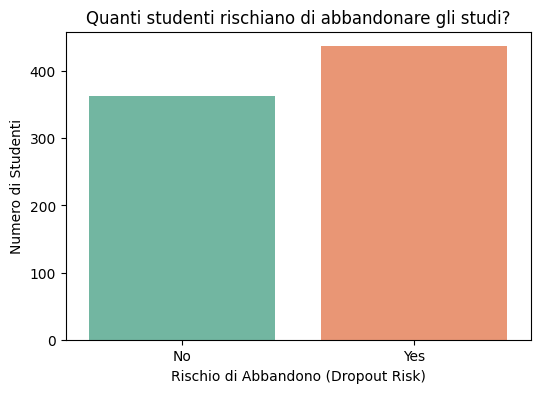

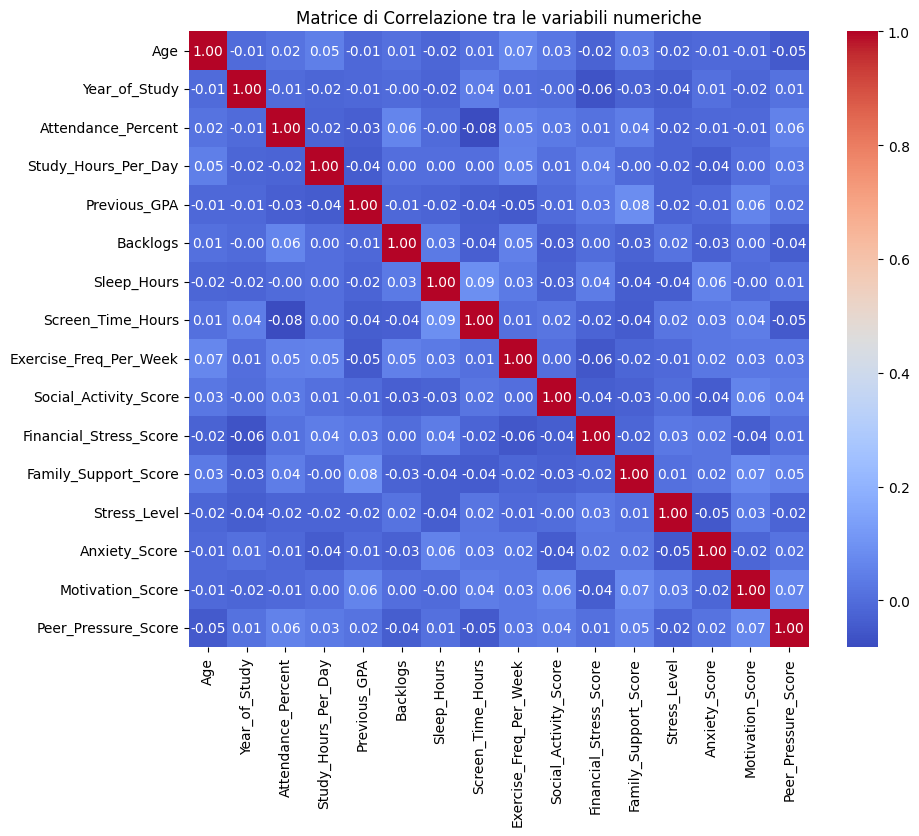

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analizzo la distribuzione della variabile target (Dropout_Risk)
print("Distribuzione del Rischio di Abbandono (Dropout_Risk):")
print(df['Dropout_Risk'].value_counts())

# Creo un grafico a barre per mostrare visivamente i dati
plt.figure(figsize=(6, 4))
sns.countplot(x='Dropout_Risk', data=df, palette='Set2')
plt.title('Quanti studenti rischiano di abbandonare gli studi?')
plt.xlabel('Rischio di Abbandono (Dropout Risk)')
plt.ylabel('Numero di Studenti')
plt.show()

print("\n" + "="*50 + "\n")

# Calcolo la correlazione solo tra le variabili numeriche del dataset
colonne_numeriche_eda = df.select_dtypes(include=['int64', 'float64'])
matrice_corr = colonne_numeriche_eda.corr()

# Genero il grafico della matrice di correlazione (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(matrice_corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Matrice di Correlazione tra le variabili numeriche')
plt.show()

# 3. Data Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# 1. Divido il dataset in domande (X) e risposte (y)
X = df.drop(columns=['Dropout_Risk', 'Burnout_Level'])
y = df['Dropout_Risk'].map({'No': 0, 'Yes': 1})

# 2. Divido subito in Train e Test per evitare il Data Leakage come spiegato a lezione
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Separo le colonne con i numeri da quelle con i testi
colonne_numeriche = X.select_dtypes(include=['int64', 'float64']).columns
colonne_testo = X.select_dtypes(include=['object']).columns

# --- PREPROCESSING DEI NUMERI ---
# Configuro l'imputer con la mediana per gestire i valori nulli (come richiesto dalla teoria)
imputer_numeri = SimpleImputer(strategy='median')
# Calcolo la mediana solo sul Train set per non inquinare il test set
X_train_num_pieni = imputer_numeri.fit_transform(X_train[colonne_numeriche])
# Applico la stessa identica mediana al Test set
X_test_num_pieni = imputer_numeri.transform(X_test[colonne_numeriche])

# Ridimensiono i valori numerici per metterli tutti sulla stessa scala
scaler = StandardScaler()
X_train_numeri_scalati = scaler.fit_transform(X_train_num_pieni)
X_test_numeri_scalati = scaler.transform(X_test_num_pieni)

# --- PREPROCESSING DEI TESTI ---
# Gestisco i testi mancanti inserendo la parola più frequente (la moda)
imputer_testo = SimpleImputer(strategy='most_frequent')
X_train_testi_pieni = imputer_testo.fit_transform(X_train[colonne_testo])
X_test_testi_pieni = imputer_testo.transform(X_test[colonne_testo])

# Trasformo le variabili categoriche in stringhe binarie (One-Hot Encoding)
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_testi_codificati = encoder.fit_transform(X_train_testi_pieni)
X_test_testi_codificati = encoder.transform(X_test_testi_pieni)

# --- UNIONE DEI DATI ---
# Unisco i blocchi numerici e testuali in un'unica matrice pronta per l'algoritmo
X_train_pronto = np.hstack([X_train_numeri_scalati, X_train_testi_codificati])
X_test_pronto = np.hstack([X_test_numeri_scalati, X_test_testi_codificati])

print("Preprocessing completato in modo semplice!")

Preprocessing completato in modo semplice!


# 4. Modellazione e Confronto Algoritmi

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Inizializzo i due modelli richiesti per il confronto
modello_logistica = LogisticRegression(random_state=42)
modello_foresta = RandomForestClassifier(random_state=42, n_estimators=100)

# Avvio l'addestramento (fit) sul Training Set che ho preparato
modello_logistica.fit(X_train_pronto, y_train)
modello_foresta.fit(X_train_pronto, y_train)

print("Modelli allenati con successo!")

Modelli allenati con successo!


# 5. Valutazione delle Performance

=== RISULTATI REGRESSIONE LOGISTICA ===
Accuracy (Frazione di predizioni corrette): 0.69375
F1-Score (Media armonica): 0.7167630057803468

Report completo:
              precision    recall  f1-score   support

           0       0.66      0.67      0.67        73
           1       0.72      0.71      0.72        87

    accuracy                           0.69       160
   macro avg       0.69      0.69      0.69       160
weighted avg       0.69      0.69      0.69       160



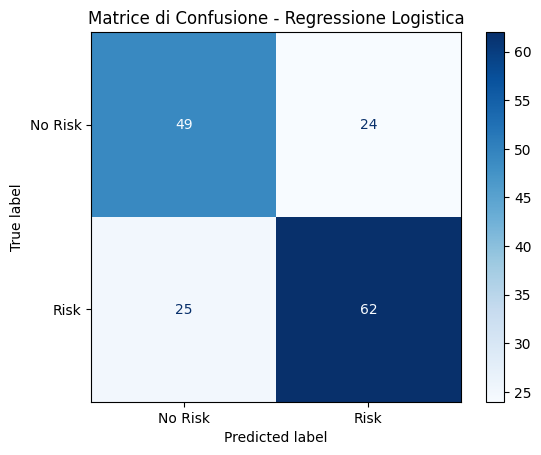



=== RISULTATI RANDOM FOREST ===
Accuracy (Frazione di predizioni corrette): 0.68125
F1-Score (Media armonica): 0.7272727272727273

Report completo:
              precision    recall  f1-score   support

           0       0.68      0.56      0.62        73
           1       0.68      0.78      0.73        87

    accuracy                           0.68       160
   macro avg       0.68      0.67      0.67       160
weighted avg       0.68      0.68      0.68       160



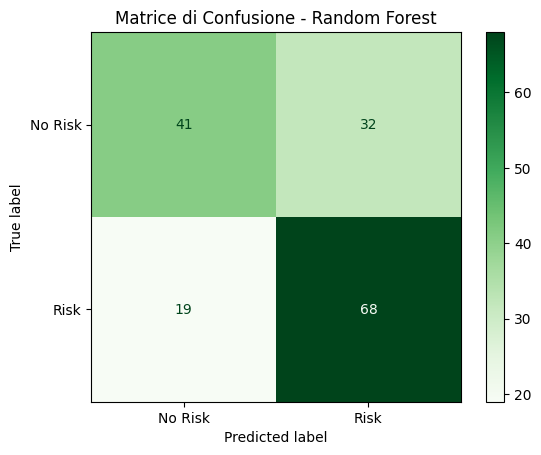

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Effettuo le previsioni sul Test Set per verificare la capacità dei modelli
pred_logistica = modello_logistica.predict(X_test_pronto)
pred_foresta = modello_foresta.predict(X_test_pronto)

# --- VALUTAZIONE REGRESSIONE LOGISTICA ---
print("=== RISULTATI REGRESSIONE LOGISTICA ===")
print("Accuracy (Frazione di predizioni corrette):", accuracy_score(y_test, pred_logistica))
print("F1-Score (Media armonica):", f1_score(y_test, pred_logistica))
print("\nReport completo:")
print(classification_report(y_test, pred_logistica))

# Disegno la Matrice di Confusione Grafica per la Regressione Logistica
cm_logistica = confusion_matrix(y_test, pred_logistica)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_logistica, display_labels=['No Risk', 'Risk'])
disp_lr.plot(cmap='Blues')
plt.title('Matrice di Confusione - Regressione Logistica')
plt.show()

print("\n" + "="*60 + "\n")

# --- VALUTAZIONE RANDOM FOREST ---
print("=== RISULTATI RANDOM FOREST ===")
print("Accuracy (Frazione di predizioni corrette):", accuracy_score(y_test, pred_foresta))
print("F1-Score (Media armonica):", f1_score(y_test, pred_foresta))
print("\nReport completo:")
print(classification_report(y_test, pred_foresta))

# Disegno la Matrice di Confusione Grafica per la Random Forest
cm_foresta = confusion_matrix(y_test, pred_foresta)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_foresta, display_labels=['No Risk', 'Risk'])
disp_rf.plot(cmap='Greens')
plt.title('Matrice di Confusione - Random Forest')
plt.show()

# 6. Interpretazione dei Risultati (Feature Importance)

/tmp/ipykernel_2091/3325208649.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importanza', y='Variabile', data=top_10_variabili, palette='viridis')


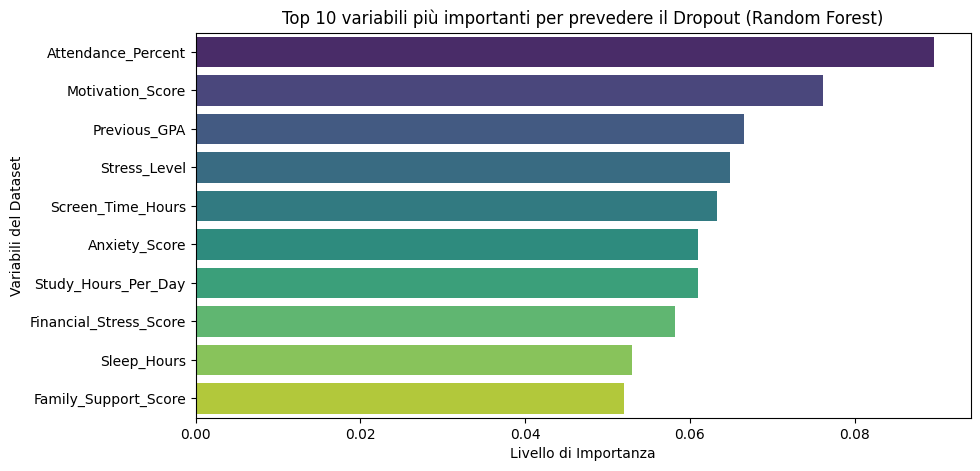

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Recupero i nomi delle colonne di testo create dall'OneHotEncoder
nomi_colonne_testo = encoder.get_feature_names_out(colonne_testo)

# Unisco i nomi delle colonne numeriche a quelle di testo per avere l'elenco completo
tutti_i_nomi = np.concatenate([colonne_numeriche, nomi_colonne_testo])

# Estraggo l'importanza delle variabili calcolata dal modello Random Forest
importanze_variabili = modello_foresta.feature_importances_

# Creo una tabella (DataFrame) per accoppiare ogni variabile alla sua importanza
tabella_importanze = pd.DataFrame({'Variabile': tutti_i_nomi, 'Importanza': importanze_variabili})

# Ordino la tabella dalla variabile più importante a quella meno importante e prendo le prime 10
top_10_variabili = tabella_importanze.sort_values(by='Importanza', ascending=False).head(10)

# Disegno il grafico a barre per mostrare i risultati visivamente
plt.figure(figsize=(10, 5))
sns.barplot(x='Importanza', y='Variabile', data=top_10_variabili, palette='viridis')
plt.title('Top 10 variabili più importanti per prevedere il Dropout (Random Forest)')
plt.xlabel('Livello di Importanza')
plt.ylabel('Variabili del Dataset')

# Mostro il grafico finale sullo schermo di Colab
plt.show()